In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
adata_embryo_14_16 = sc.read_h5ad("C:\\Users\\mca52\\Desktop\\dataset\\E14-16h_a_count_normal_stereoseq.h5ad")
adata_embryo_16_18 = sc.read_h5ad("C:\\Users\\mca52\\Desktop\\dataset\\E16-18h_a_count_normal_stereoseq.h5ad")
adata_larva_L1 = sc.read_h5ad("C:\\Users\\mca52\\Desktop\\dataset\\L1_a_count_normal_stereoseq.h5ad")
adata_larva_L2 = sc.read_h5ad("C:\\Users\\mca52\\Desktop\\dataset\\L2_a_count_normal_stereoseq.h5ad")
adata_larva_L3 = sc.read_h5ad("C:\\Users\\mca52\\Desktop\\dataset\\L3_b_count_normal_stereoseq.h5ad")

datasets = {
    "E14_16": adata_embryo_14_16,
    "E16_18": adata_embryo_16_18,
    "L1": adata_larva_L1,
    "L2": adata_larva_L2,
    "L3": adata_larva_L3
}

In [2]:
common_genes = set.intersection(
    *[set(adata.var_names) for adata in datasets.values()]
)

common_genes = list(common_genes)

print("Common genes across stages:", len(common_genes))

Common genes across stages: 11703


In [3]:
def get_expr_df(adata, genes):

    layer = adata[:, genes].layers['raw_counts']
    expr = layer.toarray() if hasattr(layer, "toarray") else layer

    return pd.DataFrame(expr, columns=genes, index=adata.obs_names)


expr_data = {}

for stage, adata in datasets.items():

    expr_data[stage] = get_expr_df(adata, common_genes)

    print(stage, expr_data[stage].shape)

E14_16 (15295, 11703)
E16_18 (14634, 11703)
L1 (17787, 11703)
L2 (64658, 11703)
L3 (43310, 11703)


In [4]:
import numpy as np
import pandas as pd

top_n = 50
chunk_size = 500
top_genes_per_stage = {}

for stage, adata in datasets.items():

    print("Processing:", stage)

    X = adata.X
    n_genes = X.shape[1]

    gene_var = np.zeros(n_genes)

    for start in range(0, n_genes, chunk_size):

        end = min(start + chunk_size, n_genes)

        X_chunk = X[:, start:end]

        if hasattr(X_chunk, "toarray"):
            X_chunk = X_chunk.toarray()

        gene_var[start:end] = np.var(X_chunk, axis=0)

    gene_var_series = pd.Series(gene_var, index=adata.var_names)

    top_genes = gene_var_series.sort_values(ascending=False).index[:top_n]

    top_genes_per_stage[stage] = set(top_genes)

    print("Top genes selected:", len(top_genes))

Processing: E14_16
Top genes selected: 50
Processing: E16_18
Top genes selected: 50
Processing: L1
Top genes selected: 50
Processing: L2
Top genes selected: 50
Processing: L3
Top genes selected: 50


In [5]:
union_genes = list(set().union(*top_genes_per_stage.values()))

print("Union gene count:", len(union_genes))
common_union_genes = set(union_genes)

for expr in expr_data.values():
    common_union_genes = common_union_genes.intersection(expr.columns)

common_union_genes = list(common_union_genes)

print("Final comparable genes:", len(common_union_genes))

Union gene count: 186
Final comparable genes: 171


In [6]:
expr_union = {}

for stage, expr in expr_data.items():

    expr_union[stage] = expr[common_union_genes]

    print(stage, expr_union[stage].shape)

E14_16 (15295, 171)
E16_18 (14634, 171)
L1 (17787, 171)
L2 (64658, 171)
L3 (43310, 171)


In [7]:
corr_matrices = {}

for stage, expr in expr_union.items():
    corr = expr.corr()
    corr_matrices[stage] = 0.5 * (1 + corr)

for stage, corr in corr_matrices.items():
    print(stage)
    print(corr.head())

E14_16
                   CR30029  pre-rRNA:CR45856     His4r   CG42815     RpS3A  \
CR30029           1.000000          0.500889  0.507400  0.499836  0.501280   
pre-rRNA:CR45856  0.500889          1.000000  0.564835  0.506910  0.504333   
His4r             0.507400          0.564835  1.000000  0.507997  0.554476   
CG42815           0.499836          0.506910  0.507997  1.000000  0.498169   
RpS3A             0.501280          0.504333  0.554476  0.498169  1.000000   

                    Jon44E  Lcp65Ag1    CG7630   ATPsynG     RpL39  ...  \
CR30029           0.499542  0.496655  0.508460  0.500687  0.501878  ...   
pre-rRNA:CR45856  0.495023  0.478899  0.552531  0.559843  0.557771  ...   
His4r             0.499067  0.512878  0.539266  0.543272  0.603688  ...   
CG42815           0.499542  0.499218  0.499000  0.495397  0.504556  ...   
RpS3A             0.496400  0.546448  0.567896  0.575667  0.672909  ...   

                     RpL21     RpS18     RpL27     RpLP2       Tm2   TpnC

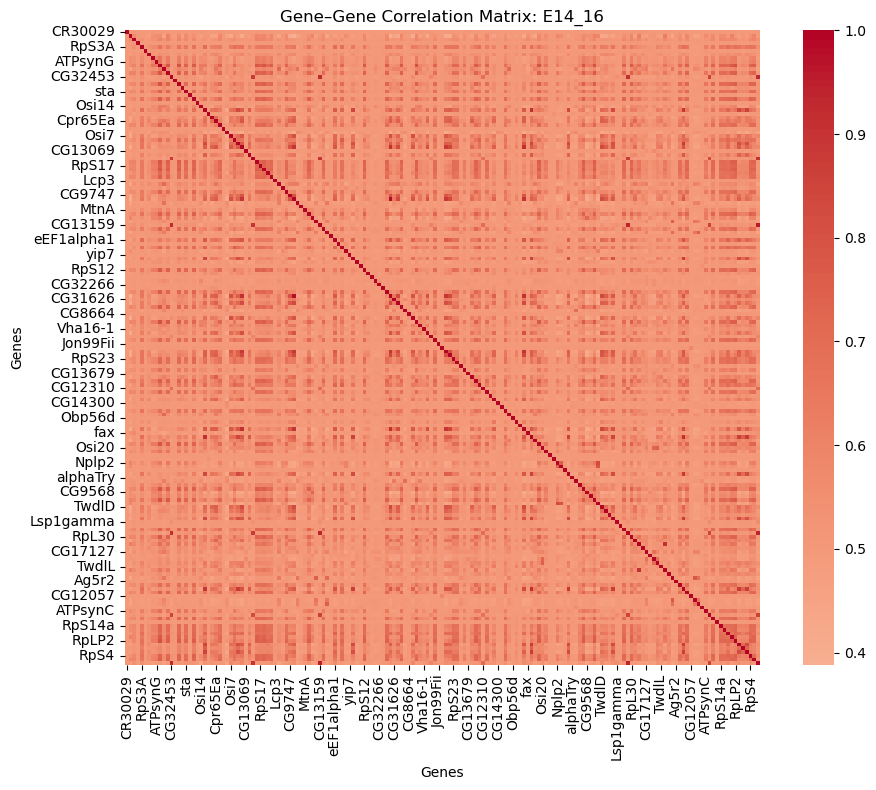

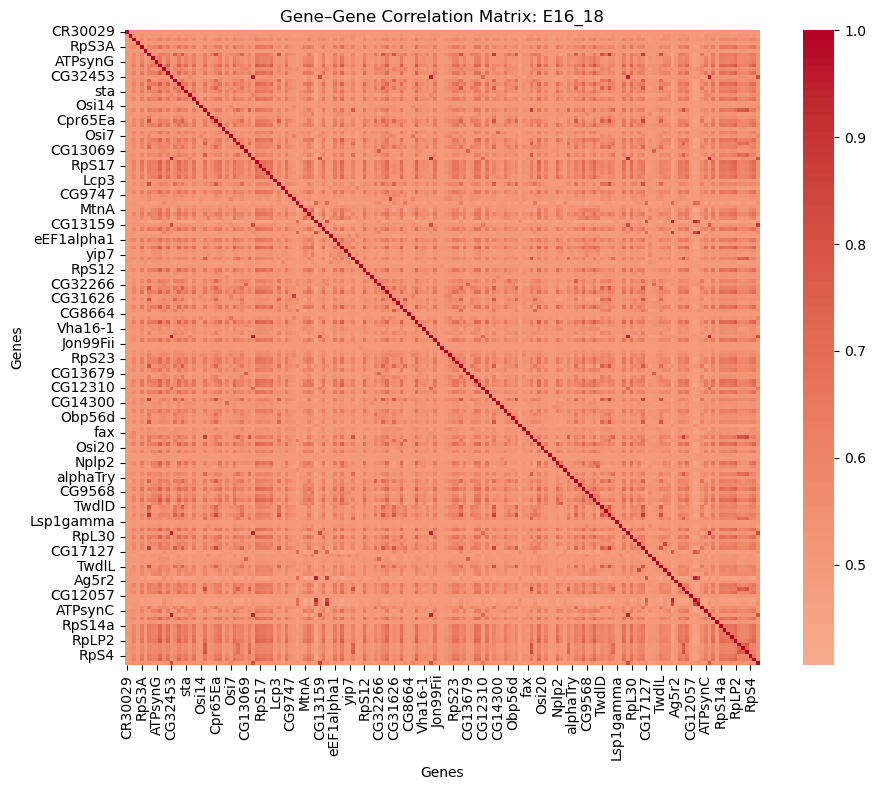

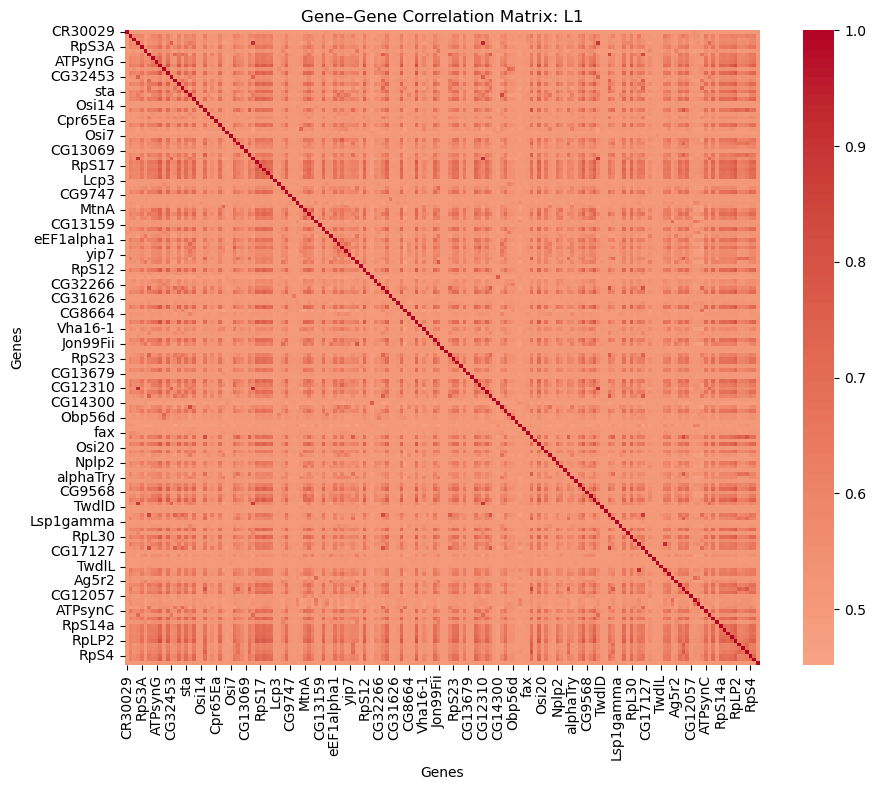

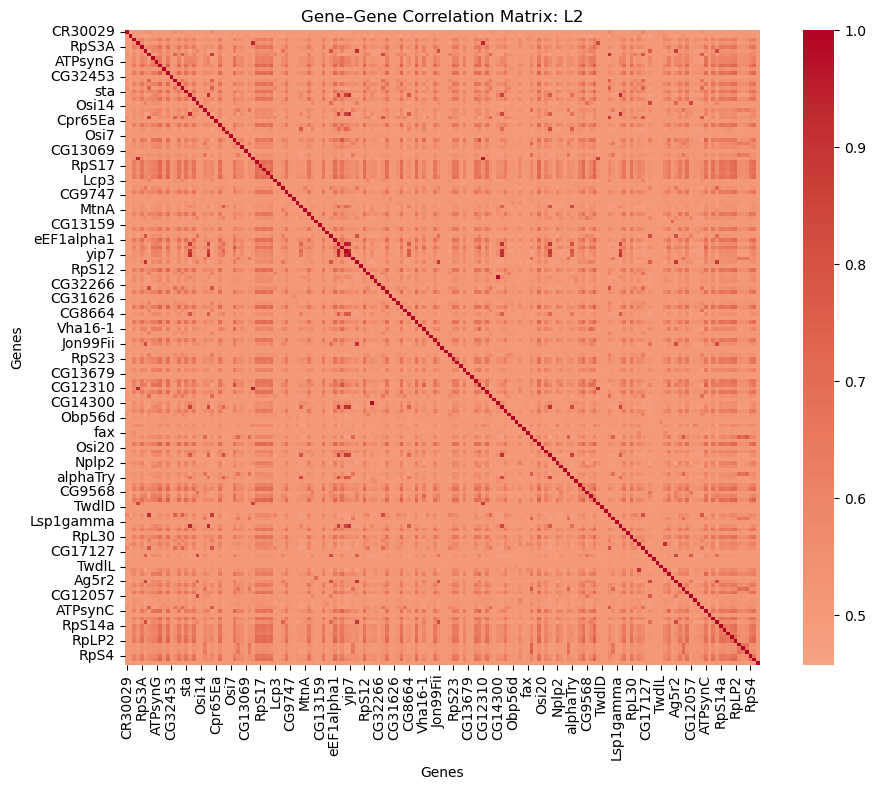

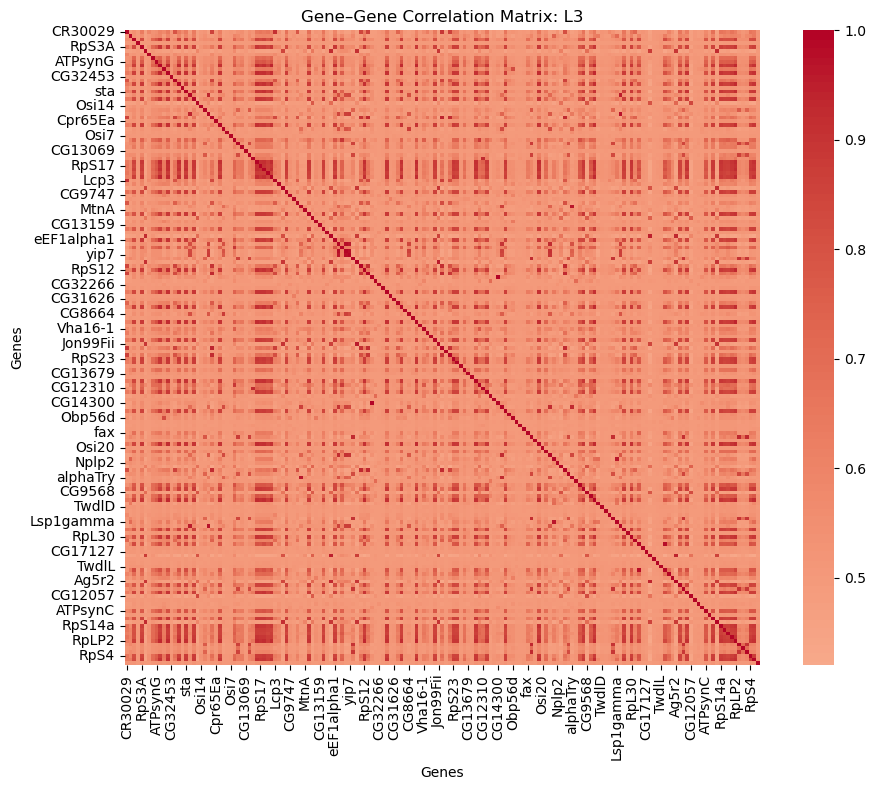

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

for stage, corr in corr_matrices.items():

    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        square=True
    )

    plt.title(f"Gene–Gene Correlation Matrix: {stage}")
    plt.xlabel("Genes")
    plt.ylabel("Genes")

    plt.tight_layout()
    plt.show()

In [9]:
import os

output_dir = r"C:\Users\mca52\Desktop\dataset"

os.makedirs(output_dir, exist_ok=True)

for stage, corr in corr_matrices.items():

    filename = os.path.join(output_dir, f"corr_matrix_{stage}.csv")

    corr.to_csv(filename)

    print(f"Saved: {filename}")

Saved: C:\Users\mca52\Desktop\dataset\corr_matrix_E14_16.csv
Saved: C:\Users\mca52\Desktop\dataset\corr_matrix_E16_18.csv
Saved: C:\Users\mca52\Desktop\dataset\corr_matrix_L1.csv
Saved: C:\Users\mca52\Desktop\dataset\corr_matrix_L2.csv
Saved: C:\Users\mca52\Desktop\dataset\corr_matrix_L3.csv


In [10]:
import numpy as np

top_percent = 5

def percentile_threshold(corr_matrix, top_percent):

    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    ).stack()

    return np.percentile(np.abs(upper_tri), 100 - top_percent)

In [11]:
adj_matrices = {}
thresholds = {}

for stage, corr in corr_matrices.items():

    print("Processing:", stage)

    threshold = percentile_threshold(corr, top_percent)
    thresholds[stage] = threshold

    adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)

    # remove self loops
    np.fill_diagonal(adj.values, 0)

    adj_matrices[stage] = adj

Processing: E14_16
Processing: E16_18
Processing: L1
Processing: L2


C:\Users\mca52\AppData\Local\Temp\ipykernel_16396\3020676684.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_16396\3020676684.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_16396\3020676684.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_16396\3020676684.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adj = corr.applymap(lambda x: 1 if abs(x) >= threshold else 0)
C:\Users\mca52\AppData\Local\Temp\ipykernel_16396\3020676684.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map

Processing: L3


In [12]:
import os

output_dir = r"C:\Users\mca52\Desktop\dataset"

# make sure the folder exists
os.makedirs(output_dir, exist_ok=True)

for stage, adj in adj_matrices.items():
    filename = os.path.join(output_dir, f"adj_matrix_{stage}.csv")
    adj.to_csv(filename)
    print(f"Saved: {filename}")

Saved: C:\Users\mca52\Desktop\dataset\adj_matrix_E14_16.csv
Saved: C:\Users\mca52\Desktop\dataset\adj_matrix_E16_18.csv
Saved: C:\Users\mca52\Desktop\dataset\adj_matrix_L1.csv
Saved: C:\Users\mca52\Desktop\dataset\adj_matrix_L2.csv
Saved: C:\Users\mca52\Desktop\dataset\adj_matrix_L3.csv


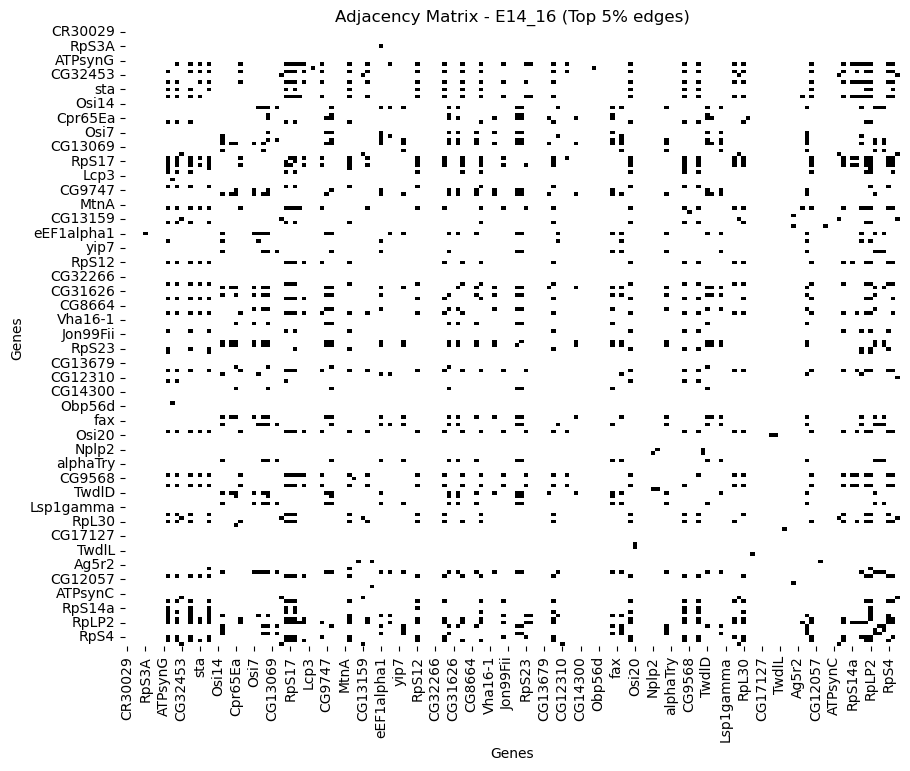

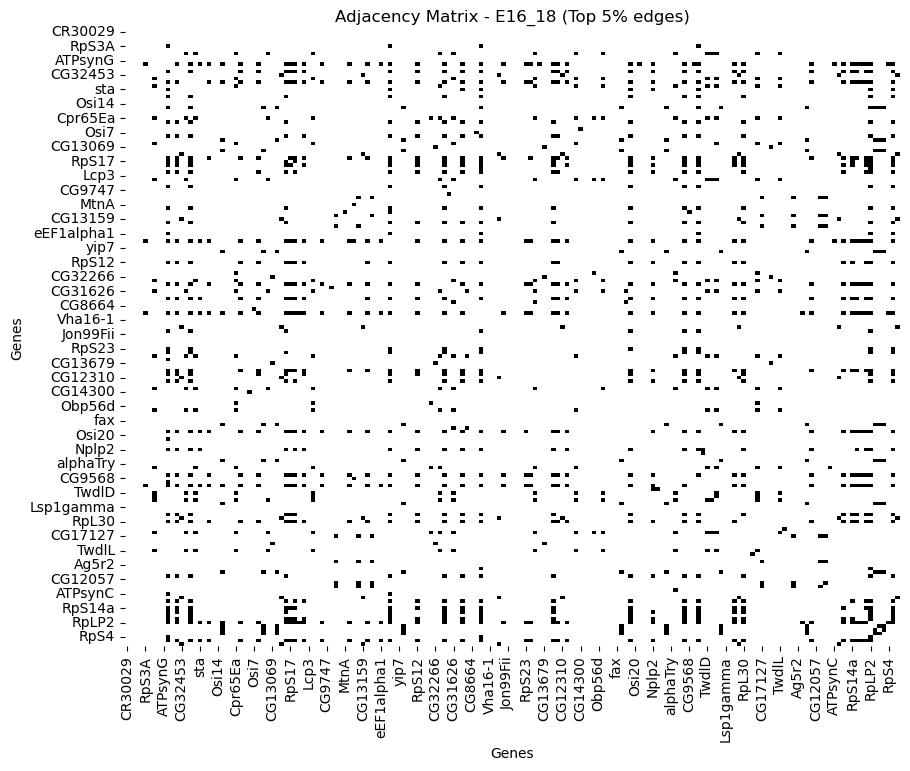

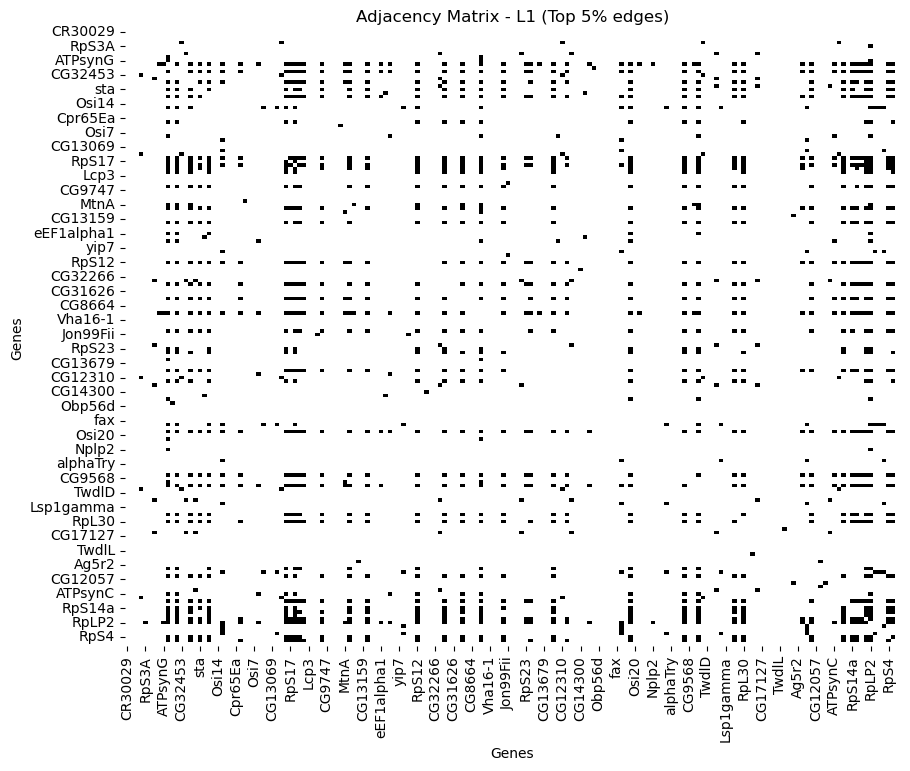

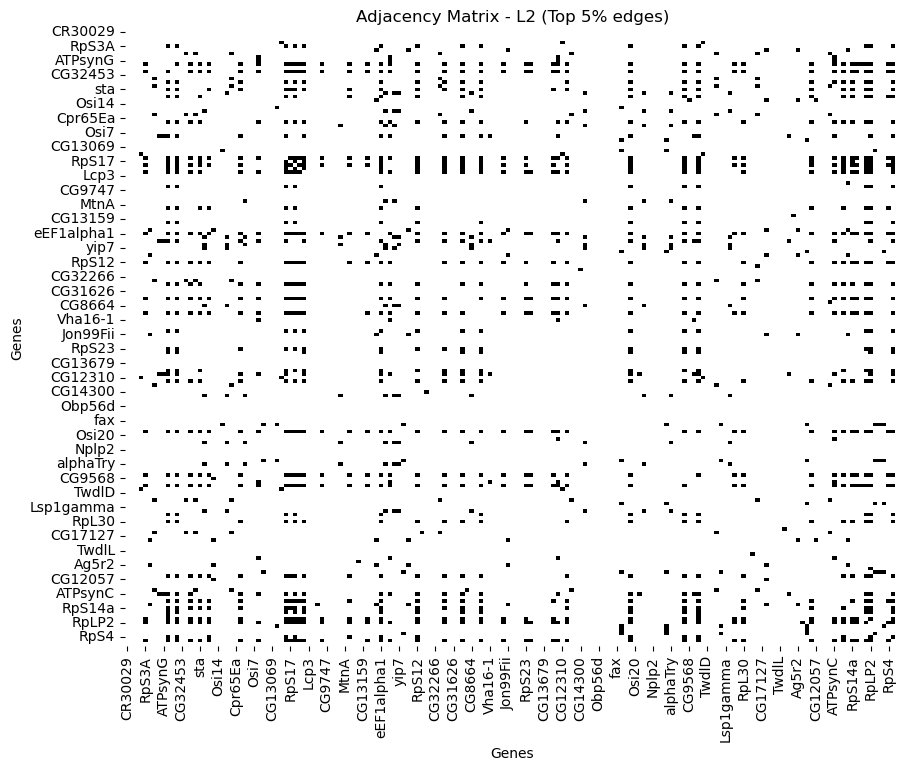

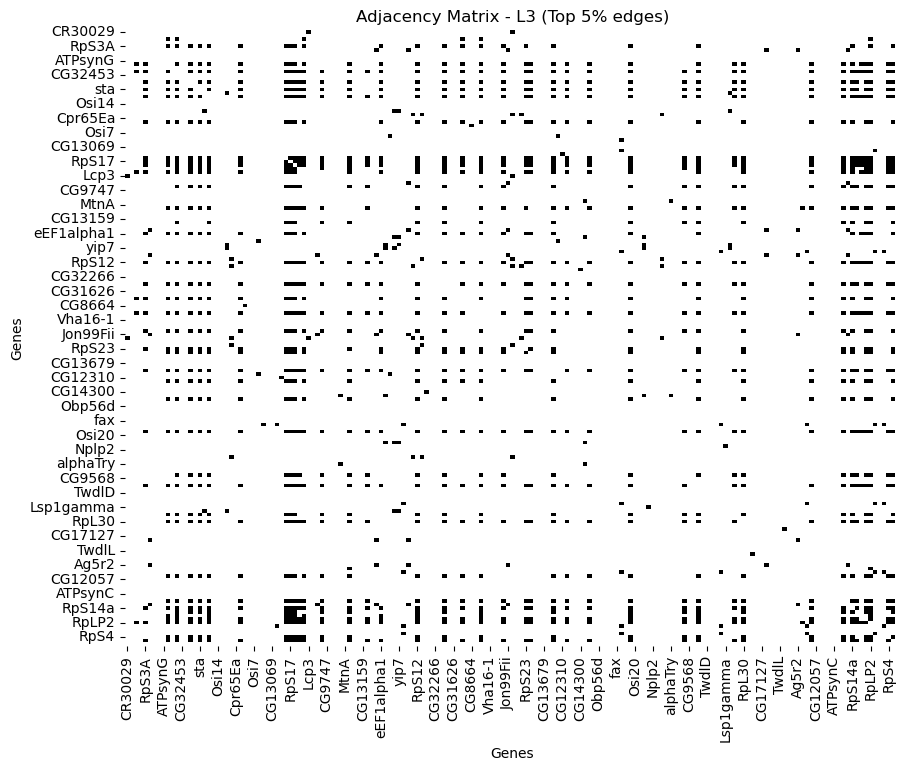

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for stage, adj in adj_matrices.items():

    plt.figure(figsize=(10,8))

    sns.heatmap(
        adj,
        cmap="Greys",
        cbar=False
    )

    plt.title(f"Adjacency Matrix - {stage} (Top {top_percent}% edges)")

    plt.xlabel("Genes")
    plt.ylabel("Genes")

    plt.show()

In [14]:
import networkx as nx
# Example for one stage
stage = 'E14_16'  # pick a stage
adj = adj_matrices[stage]

# Create undirected graph from adjacency matrix
G = nx.from_pandas_adjacency(adj)

In [15]:
import networkx as nx

connectivity_summary = {}

for stage, adj in adj_matrices.items():
    # Build undirected graph from adjacency matrix
    G = nx.from_pandas_adjacency(adj)
    
    # Check if fully connected
    is_connected = nx.is_connected(G)
    
    # Number of connected components
    n_components = nx.number_connected_components(G)
    
    # Size of largest connected component
    largest_cc_size = len(max(nx.connected_components(G), key=len))
    
    connectivity_summary[stage] = {
        "connected": is_connected,
        "num_components": n_components,
        "largest_component_size": largest_cc_size
    }
    
    print(f"{stage}: connected? {is_connected}, components: {n_components}, largest component: {largest_cc_size}")

E14_16: connected? False, components: 82, largest component: 72
E16_18: connected? False, components: 67, largest component: 64
L1: connected? False, components: 84, largest component: 64
L2: connected? False, components: 75, largest component: 50
L3: connected? False, components: 93, largest component: 42


E14_16: largest component nodes = 72


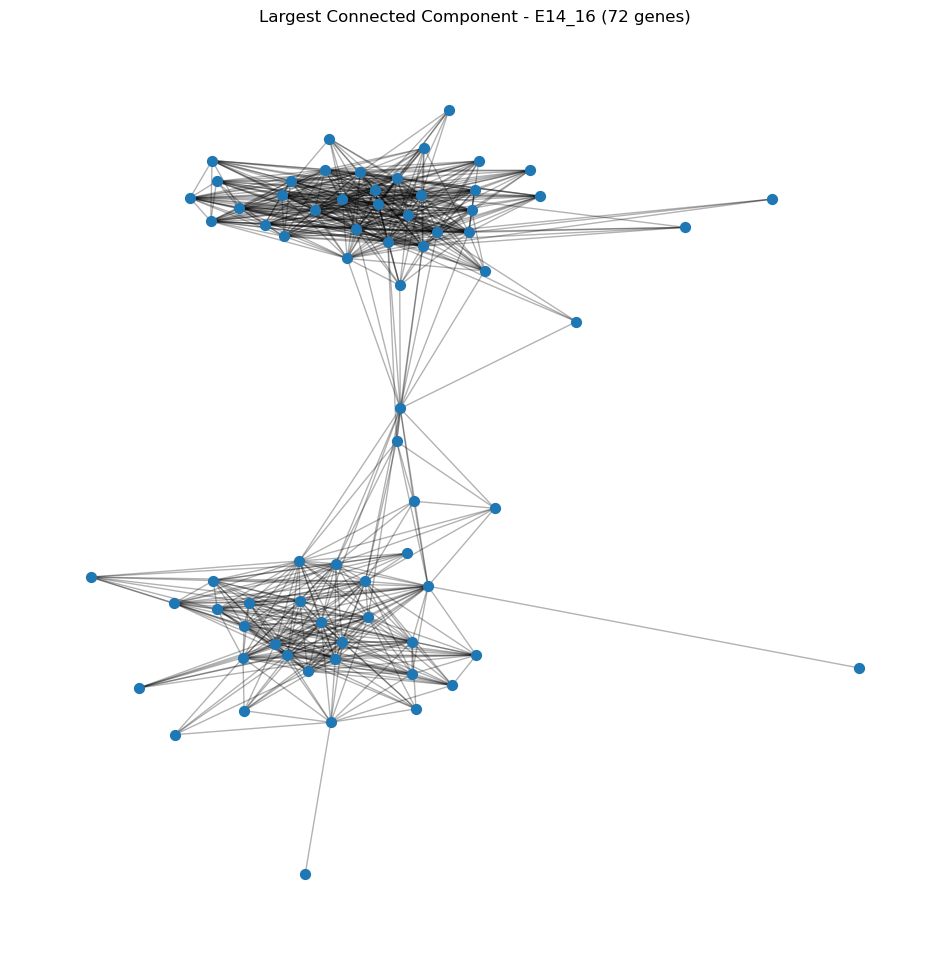

E16_18: largest component nodes = 64


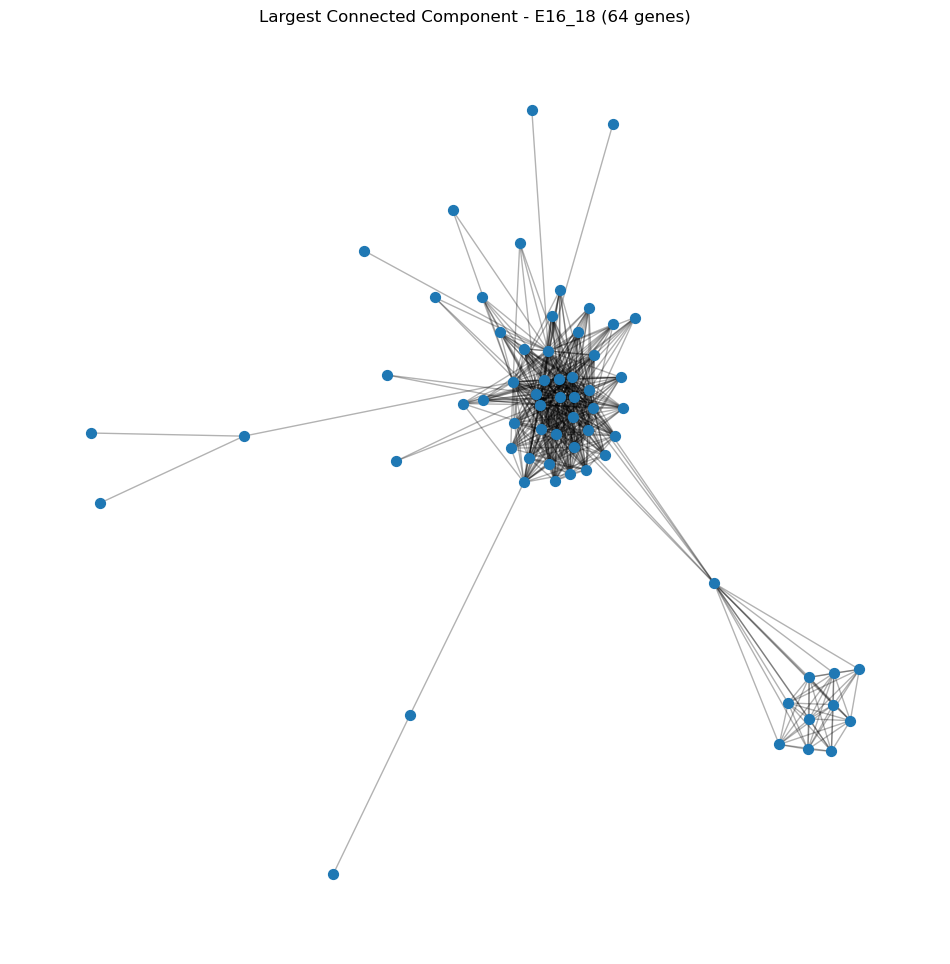

L1: largest component nodes = 64


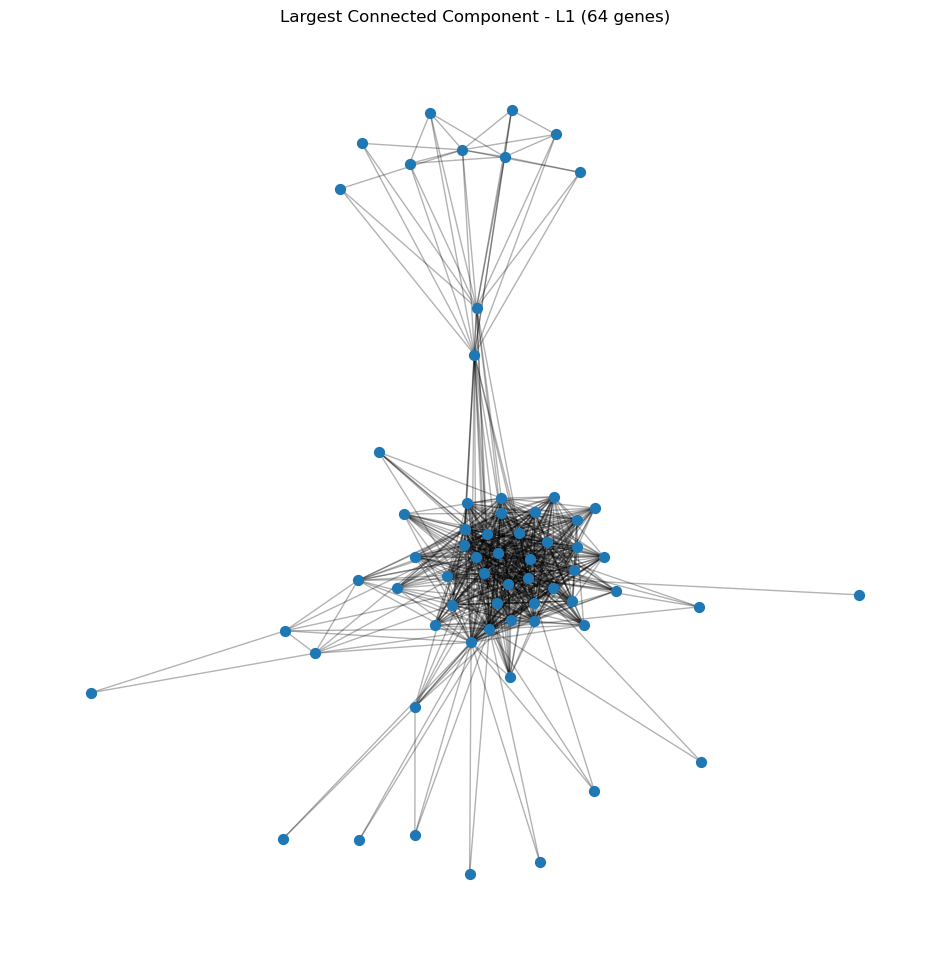

L2: largest component nodes = 50


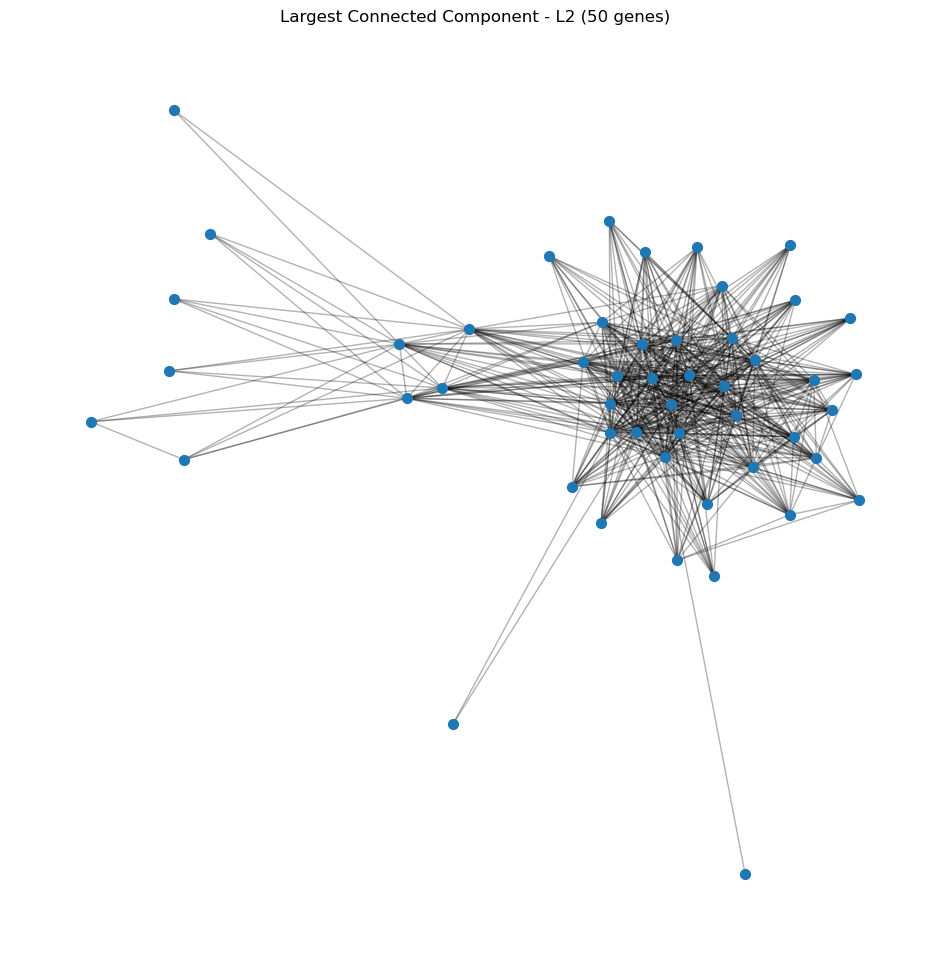

L3: largest component nodes = 42


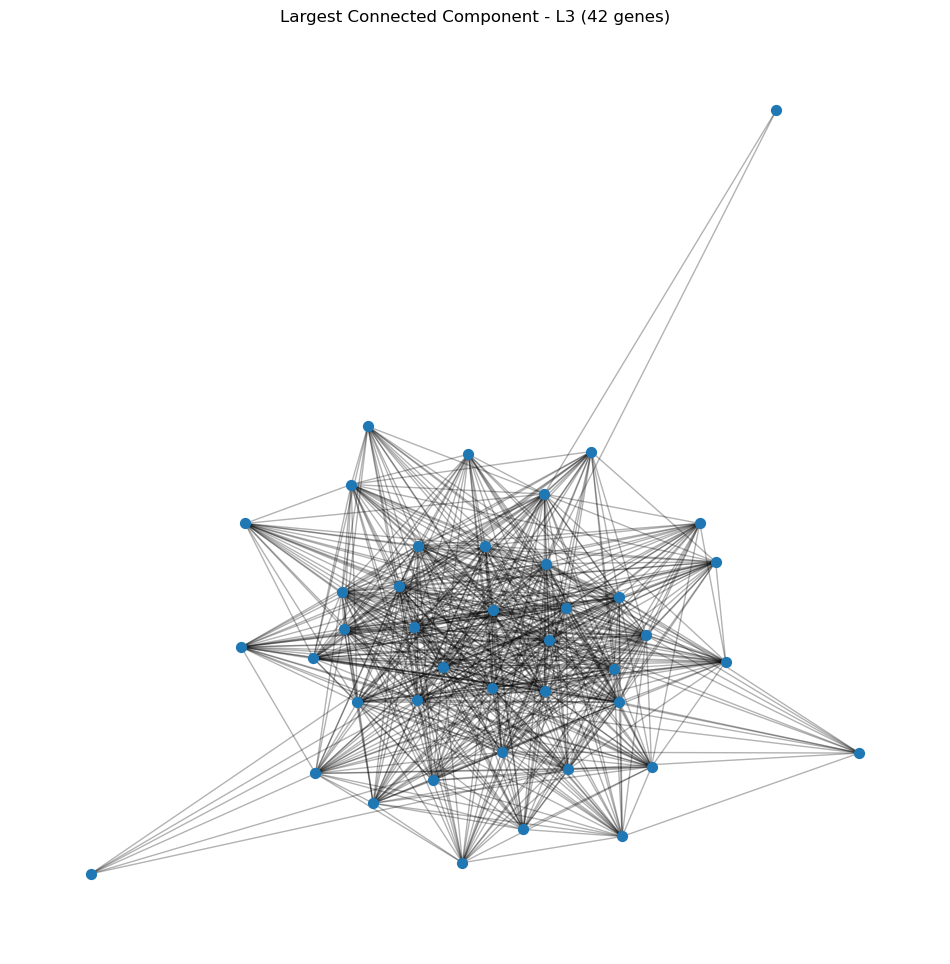

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

for stage, adj in adj_matrices.items():
    # Build undirected graph
    G = nx.from_pandas_adjacency(adj)
    
    # Extract largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_largest = G.subgraph(largest_cc).copy()
    
    print(f"{stage}: largest component nodes = {len(G_largest.nodes())}")
    
    # Plot
    plt.figure(figsize=(12,12))
    pos = nx.spring_layout(G_largest, seed=42)  # spring layout for nice spacing
    nx.draw_networkx_nodes(G_largest, pos, node_size=50)
    nx.draw_networkx_edges(G_largest, pos, alpha=0.3)
    plt.title(f"Largest Connected Component - {stage} ({len(G_largest.nodes())} genes)")
    plt.axis('off')
    plt.show()